# Crack Detection ResNet50
Transfer Learning + Fine-Tuning untuk klasifikasi retakan: Diagonal, Horizontal, Vertikal.



In [2]:
%pip install tensorflow scikit-learn matplotlib seaborn numpy pillow -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet import preprocess_input as resnet_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from PIL import Image
import random

print(f'TensorFlow version : {tf.__version__}')
print(f'GPU   : {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version : 2.19.0
GPU   : False


## Konfigurasi

In [4]:
DATASET_DIR = './dataset'
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 16
EPOCHS      = 50
NUM_CLASSES = 3
CLASS_NAMES = ['Diagonal', 'Horizontal', 'Vertikal']
TRAIN_SPLIT = 0.70
VAL_SPLIT   = 0.15
TEST_SPLIT  = 0.15
SEED        = 42

MODEL_NAME  = 'ResNet50'

print(f'Dataset  : {DATASET_DIR}')
print(f'Img Size : {IMG_SIZE}')
print(f'Model    : {MODEL_NAME}')

Dataset  : ./dataset
Img Size : (224, 224)
Model    : ResNet50


##  Dataset

  Diagonal    :  540 gambar
  Horizontal  :  501 gambar
  Vertikal    :  500 gambar

  Train      : ~1078 gambar
  Validation : ~231 gambar
  Test       : ~231 gambar


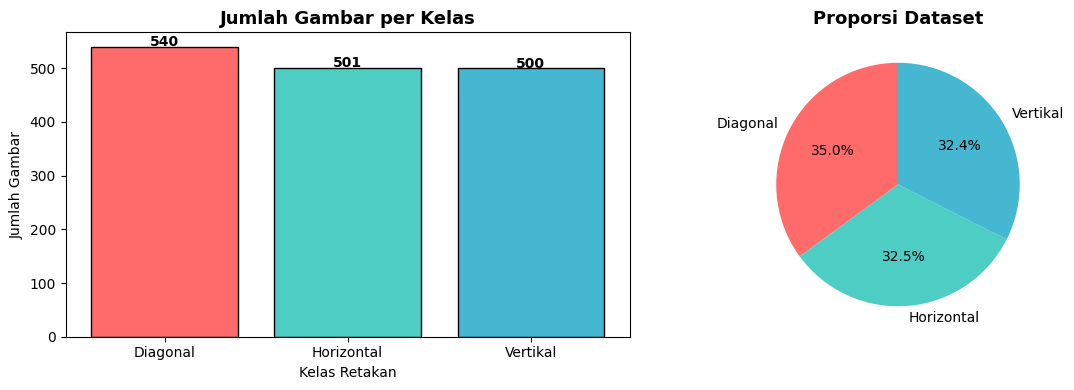

In [5]:
assert os.path.exists(DATASET_DIR), f'no dataset: {DATASET_DIR}'

total  = 0
counts = {}
for cls in CLASS_NAMES:
    cls_path = os.path.join(DATASET_DIR, cls)
    if os.path.exists(cls_path):
        n = len([f for f in os.listdir(cls_path)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))])
        counts[cls] = n
        total += n
        print(f'  {cls:12s}: {n:4d} gambar')
    else:
        print(f'  {cls} tidak ditemukan!')

print(f'\n  Train      : ~{int(total*TRAIN_SPLIT)} gambar')
print(f'  Validation : ~{int(total*VAL_SPLIT)} gambar')
print(f'  Test       : ~{int(total*TEST_SPLIT)} gambar')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(counts.keys(), counts.values(), color=['#FF6B6B','#4ECDC4','#45B7D1'], edgecolor='black')
axes[0].set_title('Jumlah Gambar per Kelas', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Kelas Retakan')
axes[0].set_ylabel('Jumlah Gambar')
for i,(k,v) in enumerate(counts.items()):
    axes[0].text(i, v+1, str(v), ha='center', fontweight='bold')
axes[1].pie(counts.values(), labels=counts.keys(), autopct='%1.1f%%',
            colors=['#FF6B6B','#4ECDC4','#45B7D1'], startangle=90)
axes[1].set_title('Proporsi Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('distribusi_dataset_resnet50.png', dpi=150, bbox_inches='tight')
plt.show()

## Load & Split Dataset (70/15/15)

In [6]:
all_images, all_labels = [], []
for label_idx, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(DATASET_DIR, cls)
    for fname in os.listdir(cls_path):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
            all_images.append(os.path.join(cls_path, fname))
            all_labels.append(label_idx)

combined = list(zip(all_images, all_labels))
random.seed(SEED)
random.shuffle(combined)
all_images, all_labels = zip(*combined)
all_images = list(all_images)
all_labels = list(all_labels)

X_train, X_temp, y_train, y_temp = train_test_split(
    all_images, all_labels,
    test_size=(VAL_SPLIT + TEST_SPLIT),
    random_state=SEED, stratify=all_labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5,
    random_state=SEED, stratify=y_temp
)

print(f'  Train      : {len(X_train):4d} gambar ({len(X_train)/len(all_images)*100:.1f}%)')
print(f'  Validation : {len(X_val):4d} gambar ({len(X_val)/len(all_images)*100:.1f}%)')
print(f'  Test       : {len(X_test):4d} gambar ({len(X_test)/len(all_images)*100:.1f}%)')

  Train      : 1078 gambar (70.0%)
  Validation :  231 gambar (15.0%)
  Test       :  232 gambar (15.1%)


## Preprocessing & Augmentasi



In [7]:
RESIZE_TO   = 256   # resize shortest side ke 256 
CROP_SIZE   = 224   # final crop ke 224x224


def resize_preserve_aspect(img):
    """Resize agar sisi terpendek = RESIZE_TO, pertahankan aspek rasio."""
    shape   = tf.shape(img)
    h       = tf.cast(shape[0], tf.float32)
    w       = tf.cast(shape[1], tf.float32)

    scale   = tf.cast(RESIZE_TO, tf.float32) / tf.minimum(h, w)

    new_h   = tf.cast(tf.round(h * scale), tf.int32)
    new_w   = tf.cast(tf.round(w * scale), tf.int32)

    new_h   = tf.maximum(new_h, RESIZE_TO)
    new_w   = tf.maximum(new_w, RESIZE_TO)

    img     = tf.image.resize(img, [new_h, new_w],
                              method=tf.image.ResizeMethod.BILINEAR)
    return img


def center_crop(img):
    shape  = tf.shape(img)
    h, w   = shape[0], shape[1]
    offset_h = (h - CROP_SIZE) // 2
    offset_w = (w - CROP_SIZE) // 2
    img    = tf.image.crop_to_bounding_box(img, offset_h, offset_w,
                                           CROP_SIZE, CROP_SIZE)
    return img

def load_and_resize(path, label):
    img   = tf.io.read_file(path)
    img   = tf.image.decode_image(img, channels=3, expand_animations=False)
    img   = tf.cast(img, tf.float32)          # [0, 255]
    img   = resize_preserve_aspect(img)        # shortest side = 256
    label = tf.one_hot(label, NUM_CLASSES)
    return img, label

def train_crop_and_augment(img, label):
    # Random crop: posisi crop random di dalam area 256x256
    img = tf.image.random_crop(img, size=[CROP_SIZE, CROP_SIZE, 3])

    # ============================================================
    # AUGMENTASI ORIENTASI - penting agar model tidak bias orientasi
    # Tanpa ini, model cenderung memprediksi kelas yang paling
    # banyak muncul dalam data training (mis. Vertikal).
    # ============================================================

    # Random flip horizontal (kiri-kanan)
    img = tf.image.random_flip_left_right(img)

    # Random flip vertikal (atas-bawah)
    img = tf.image.random_flip_up_down(img)

    # Random rotasi 90 derajat (0, 90, 180, 270)
    # SANGAT PENTING untuk retakan diagonal/horizontal agar model
    # belajar bahwa orientasi gambar bukan fitur yang relevan
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    img = tf.image.rot90(img, k=k)

    # Augmentasi warna ringan (setelah crop, masih di range [0,255])
    img = tf.image.random_brightness(img, max_delta=0.2 * 255.0)
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
    img = tf.clip_by_value(img, 0.0, 255.0)
    return img, label


def val_test_crop(img, label):
    img = center_crop(img)
    return img, label


def apply_normalize(img, label):
    """Terapkan preprocessing ResNet50 (mean subtraction BGR)."""
    img = resnet_preprocess(img)
    return img, label

def make_dataset(paths, labels, is_training=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_and_resize, num_parallel_calls=tf.data.AUTOTUNE)

    if is_training:
        ds = ds.map(train_crop_and_augment, num_parallel_calls=tf.data.AUTOTUNE)
    else:
        ds = ds.map(val_test_crop, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.map(apply_normalize, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=500, seed=SEED)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_dataset(X_train, y_train, is_training=True,  shuffle=True)
val_ds   = make_dataset(X_val,   y_val,   is_training=False, shuffle=False)
test_ds  = make_dataset(X_test,  y_test,  is_training=False, shuffle=False)

print(f'  Train batches      : {len(train_ds)}')
print(f'  Validation batches : {len(val_ds)}')
print(f'  Test batches       : {len(test_ds)}')
print()
print('  Augmentasi Training yang digunakan:')
print('  - Random crop (256 -> 224)')
print('  - Random flip horizontal')
print('  - Random flip vertikal')
print('  - Random rotasi 90 derajat (0/90/180/270)')
print('  - Random brightness & contrast')

  Train batches      : 68
  Validation batches : 15
  Test batches       : 15

  Augmentasi Training yang digunakan:
  - Random crop (256 -> 224)
  - Random flip horizontal
  - Random flip vertikal
  - Random rotasi 90 derajat (0/90/180/270)
  - Random brightness & contrast


## Build Model ResNet50

 Unfreeze 40% layer terakhir (proporsional).  
 ResNet50 bisa pakai LR 1e-4 karena arsitekturnya lebih toleran.

In [9]:
def build_resnet50():
    base = ResNet50(
        input_shape=(*IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )

    # Freeze semua layer dahulu
    base.trainable = False

    #  Unfreeze 40% layer terakhir (proporsional)
    n_layers      = len(base.layers)
    unfreeze_from = int(n_layers * 0.6)
    for layer in base.layers[unfreeze_from:]:
        layer.trainable = True

    print(f'  Total layer backbone : {n_layers}')
    print(f'  Layer yang di-unfreeze: {n_layers - unfreeze_from} ({(1-0.6)*100:.0f}%)')

    inputs = keras.Input(shape=(*IMG_SIZE, 3))

    #  training=True agar BatchNorm di backbone terupdate saat fine-tuning
    x = base(inputs, training=True)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='gelu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='gelu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name=MODEL_NAME)

    # ResNet lebih toleran, bisa pakai LR 1e-4
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    total_p = model.count_params()
    train_p = sum([tf.size(w).numpy() for w in model.trainable_weights])
    print(f'  Total params     : {total_p:,}')
    print(f'  Trainable params : {train_p:,}')
    return model

model = build_resnet50()

  Total layer backbone : 175
  Layer yang di-unfreeze: 70 (40%)
  Total params     : 24,153,731
  Trainable params : 19,749,891


## Training

In [9]:
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-8, verbose=1),
    ModelCheckpoint(filepath=f'best_{MODEL_NAME}.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=0)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 180s 2s/step - accuracy: 0.5312 - loss: 1.1431 - val_accuracy: 0.8485 - val_loss: 0.4794 - learning_rate: 1.0000e-04
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.8652 - loss: 0.3617 - val_accuracy: 0.9048 - val_loss: 0.2303 - learning_rate: 1.0000e-04
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - accuracy: 0.9145 - loss: 0.2548 - val_accuracy: 0.9177 - val_loss: 0.2744 - learning_rate: 1.0000e-04
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.9333 - loss: 0.1962 - val_accuracy: 0.9221 - val_loss: 0.2360 - learning_rate: 1.0000e-04
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.9333 - loss: 0.2072 - val_accuracy: 0.9177 - val_loss: 0.2300 - learning_rate: 1.0000e-04
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.9428 - loss: 0.1502 - val_accuracy: 0.9437 - val_loss: 0.2838 - learning_rate: 1.0000e-04
Epoch 7/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - accuracy: 0.9654 

## Grafik Training History

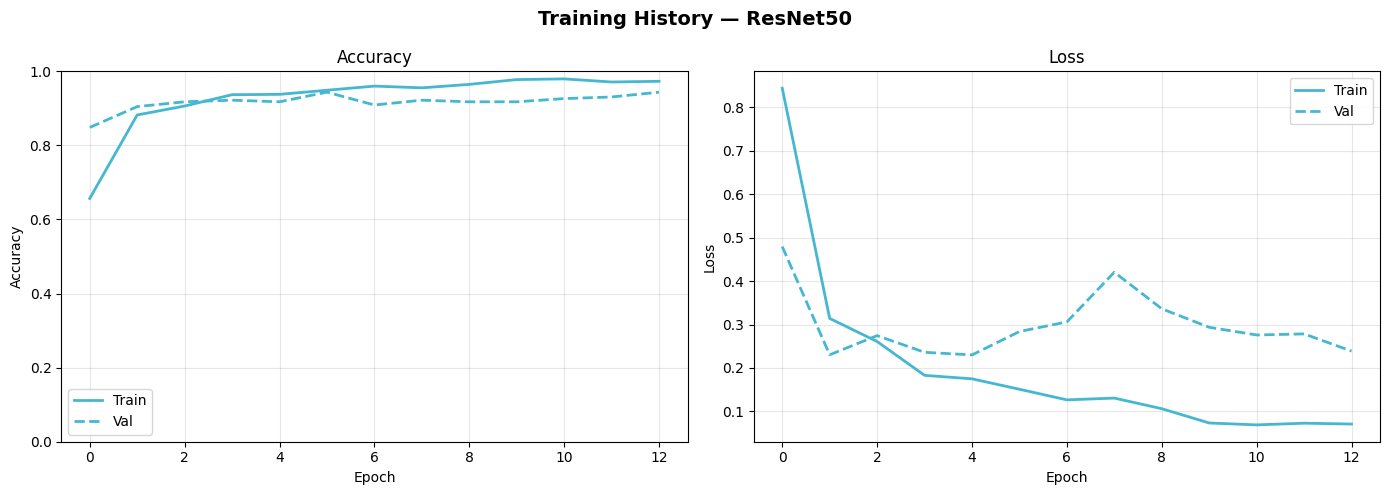

In [10]:
from matplotlib.ticker import MaxNLocator

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Training History — {MODEL_NAME}', fontsize=14, fontweight='bold')
color = '#45B7D1'

axes[0].plot(history.history['accuracy'], label='Train', color=color, linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val', color=color, linewidth=2, linestyle='--')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1])

axes[1].plot(history.history['loss'], label='Train', color=color, linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val', color=color, linewidth=2, linestyle='--')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'training_history_{MODEL_NAME}.png', dpi=150, bbox_inches='tight')
plt.show()

## Evaluasi pada Test Set

In [11]:
loss, acc = model.evaluate(test_ds, verbose=1)
print(f'\n  Test Loss     : {loss:.4f}')
print(f'  Test Accuracy : {acc*100:.2f}%')

y_true_all, y_pred_all = [], []
for imgs, labels in test_ds:
    y_true_all.extend(np.argmax(labels.numpy(), axis=1))
    preds = model.predict(imgs, verbose=0)
    y_pred_all.extend(np.argmax(preds, axis=1))
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 849ms/step - accuracy: 0.9560 - loss: 0.2933

  Test Loss     : 0.2390
  Test Accuracy : 95.69%


## Confusion Matrix

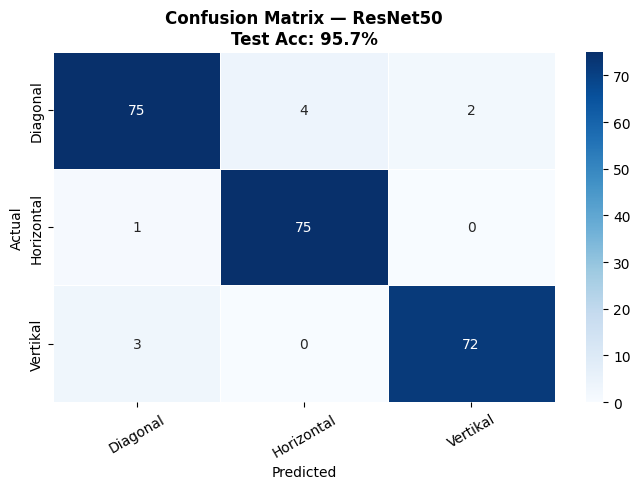

In [12]:
cm = confusion_matrix(y_true_all, y_pred_all)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cmap='Blues', linewidths=0.5)
plt.title(f'Confusion Matrix — {MODEL_NAME}\nTest Acc: {acc*100:.1f}%', fontsize=12, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f'confusion_matrix_{MODEL_NAME}.png', dpi=150, bbox_inches='tight')
plt.show()

## Classification Report

In [20]:

print(classification_report(y_true_all, y_pred_all, target_names=CLASS_NAMES))

import pandas as pd
best_val_acc = max(history.history['val_accuracy'])
df_result = pd.DataFrame([{
    'Model'       : MODEL_NAME,
    'Val Acc (%)' : f'{best_val_acc*100:.2f}',
    'Test Acc (%)': f'{acc*100:.2f}',
    'Precision'   : f'{precision_score(y_true_all, y_pred_all, average="macro")*100:.2f}',
    'Recall'      : f'{recall_score(y_true_all, y_pred_all, average="macro")*100:.2f}',
    'F1-Score'    : f'{f1_score(y_true_all, y_pred_all, average="macro")*100:.2f}',
}])
print(df_result.to_string(index=False))
df_result.to_csv(f'hasil_{MODEL_NAME}.csv', index=False)

              precision    recall  f1-score   support

    Diagonal       0.95      0.93      0.94        81
  Horizontal       0.95      0.99      0.97        76
    Vertikal       0.97      0.96      0.97        75

    accuracy                           0.96       232
   macro avg       0.96      0.96      0.96       232
weighted avg       0.96      0.96      0.96       232

   Model Val Acc (%) Test Acc (%) Precision Recall F1-Score
ResNet50       94.37        95.69     95.72  95.76    95.72


## Uji Gambar Custom

Loading TFLite model: cracksense_ResNet50.tflite
  Input  : shape=[  1 224 224   3], dtype=<class 'numpy.float32'>
  Output : shape=[1 3], dtype=<class 'numpy.float32'>

INFERENSI TFLITE - GAMBAR CUSTOM
Model : cracksense_ResNet50.tflite
Kelas : ['Diagonal', 'Horizontal', 'Vertikal']


=== Uji Gambar: ./dataset/test/horizontal_1.png ===


d:\anaconda\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


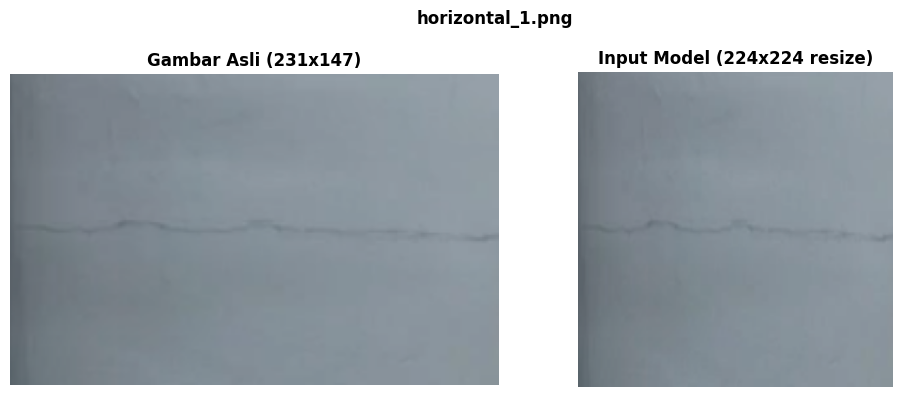

  Backend    : TFLite (cracksense_ResNet50.tflite)
  Metode     : TFLite + TTA (4 varian orientasi)
  Prediksi   : Horizontal
  Keyakinan  : 74.70%
    Diagonal    :   0.25% 
    Horizontal  :  74.70% |||||||||||||||||||||||||||||
    Vertikal    :  25.06% ||||||||||

=== Uji Gambar: ./dataset/test/horizontal_2.png ===


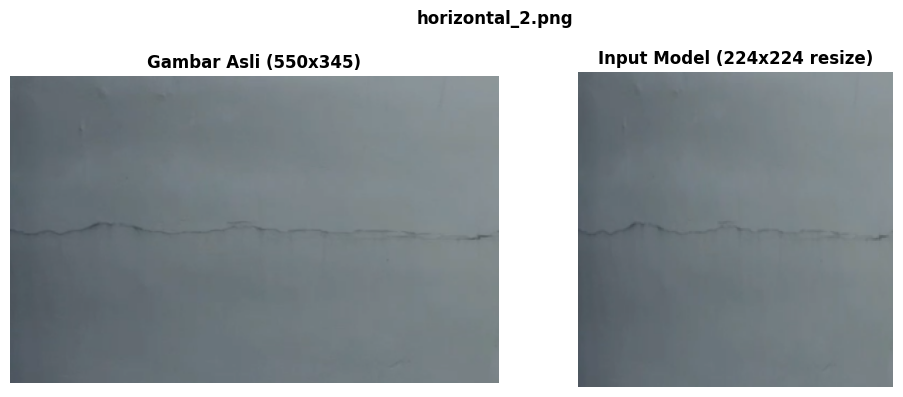

  Backend    : TFLite (cracksense_ResNet50.tflite)
  Metode     : TFLite + TTA (4 varian orientasi)
  Prediksi   : Horizontal
  Keyakinan  : 73.65%
    Diagonal    :   1.27% 
    Horizontal  :  73.65% |||||||||||||||||||||||||||||
    Vertikal    :  25.08% ||||||||||

=== Uji Gambar: ./dataset/test/horizontal_3.png ===


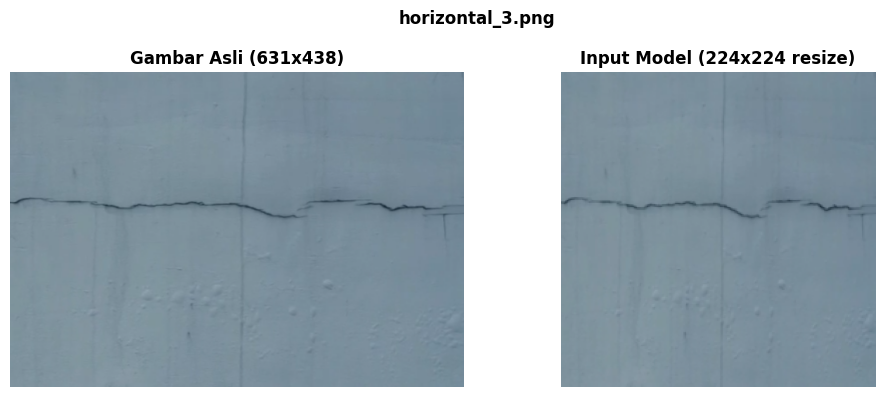

  Backend    : TFLite (cracksense_ResNet50.tflite)
  Metode     : TFLite + TTA (4 varian orientasi)
  Prediksi   : Horizontal
  Keyakinan  : 75.00%
    Diagonal    :   0.00% 
    Horizontal  :  75.00% ||||||||||||||||||||||||||||||
    Vertikal    :  25.00% |||||||||

=== Uji Gambar: ./dataset/test/horizontal_4.png ===


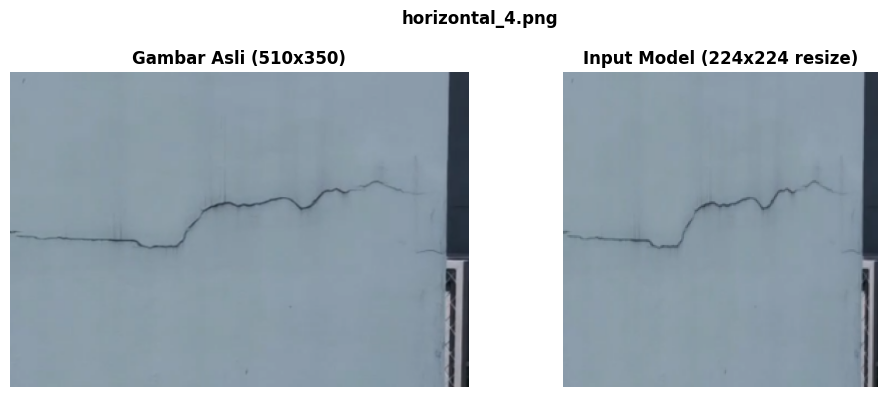

  Backend    : TFLite (cracksense_ResNet50.tflite)
  Metode     : TFLite + TTA (4 varian orientasi)
  Prediksi   : Horizontal
  Keyakinan  : 69.34%
    Diagonal    :   5.80% ||
    Horizontal  :  69.34% |||||||||||||||||||||||||||
    Vertikal    :  24.85% |||||||||

=== Uji Gambar: ./dataset/test/horizontal_5.png ===


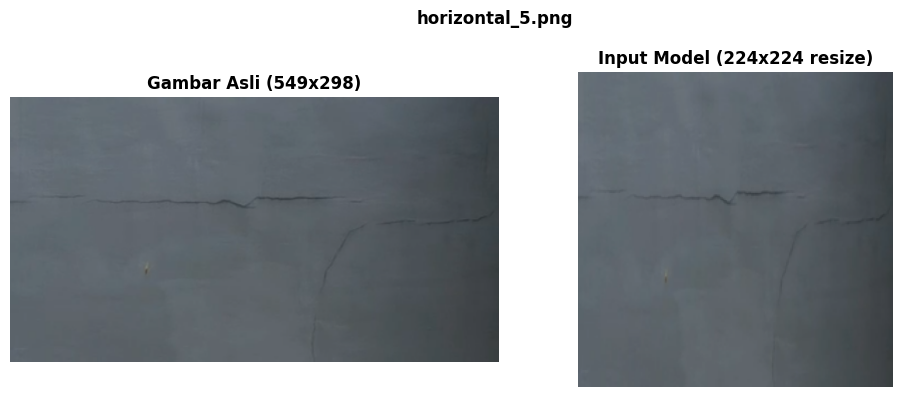

  Backend    : TFLite (cracksense_ResNet50.tflite)
  Metode     : TFLite + TTA (4 varian orientasi)
  Prediksi   : Horizontal
  Keyakinan  : 74.97%
    Diagonal    :   0.03% 
    Horizontal  :  74.97% |||||||||||||||||||||||||||||
    Vertikal    :  25.00% ||||||||||

=== Uji Gambar: ./dataset/test/vertikal_1.png ===


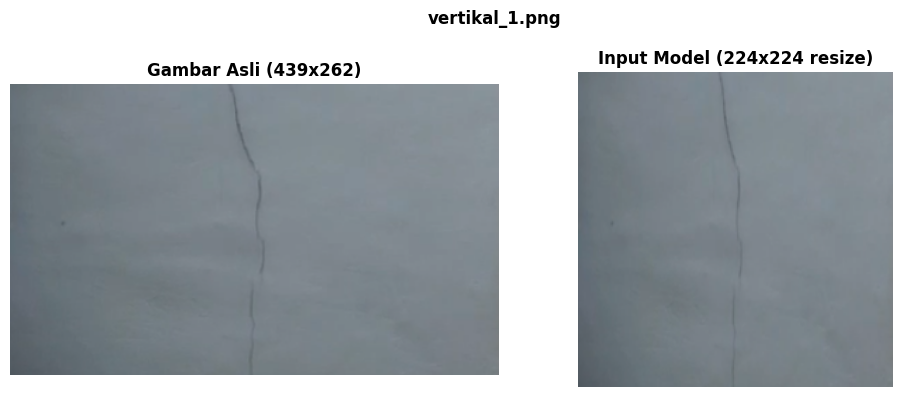

  Backend    : TFLite (cracksense_ResNet50.tflite)
  Metode     : TFLite + TTA (4 varian orientasi)
  Prediksi   : Vertikal
  Keyakinan  : 74.93%
    Diagonal    :   0.61% 
    Horizontal  :  24.46% |||||||||
    Vertikal    :  74.93% |||||||||||||||||||||||||||||

=== Uji Gambar: ./dataset/test/vertikal_2.png ===


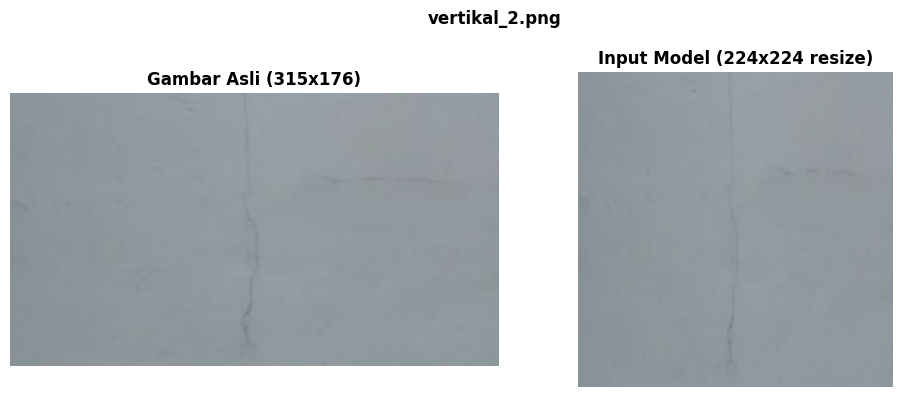

  Backend    : TFLite (cracksense_ResNet50.tflite)
  Metode     : TFLite + TTA (4 varian orientasi)
  Prediksi   : Vertikal
  Keyakinan  : 75.22%
    Diagonal    :   0.36% 
    Horizontal  :  24.41% |||||||||
    Vertikal    :  75.22% ||||||||||||||||||||||||||||||

=== Uji Gambar: ./dataset/test/vertikal_3.png ===


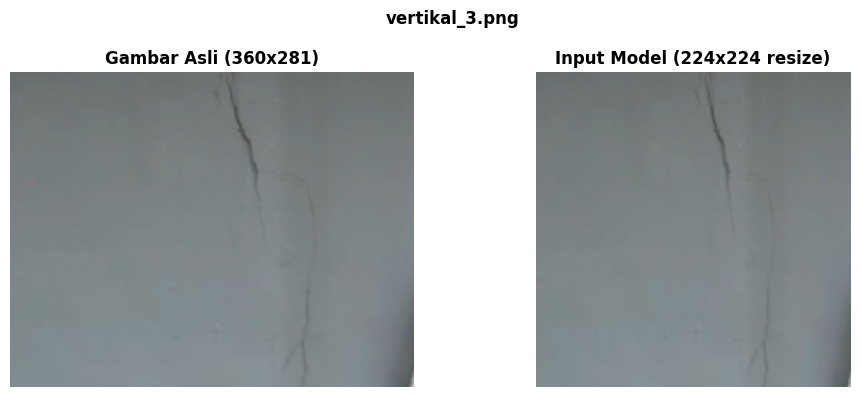

  Backend    : TFLite (cracksense_ResNet50.tflite)
  Metode     : TFLite + TTA (4 varian orientasi)
  Prediksi   : Vertikal
  Keyakinan  : 75.02%
    Diagonal    :   0.09% 
    Horizontal  :  24.89% |||||||||
    Vertikal    :  75.02% ||||||||||||||||||||||||||||||

=== Uji Gambar: ./dataset/test/vertikal_4.png ===


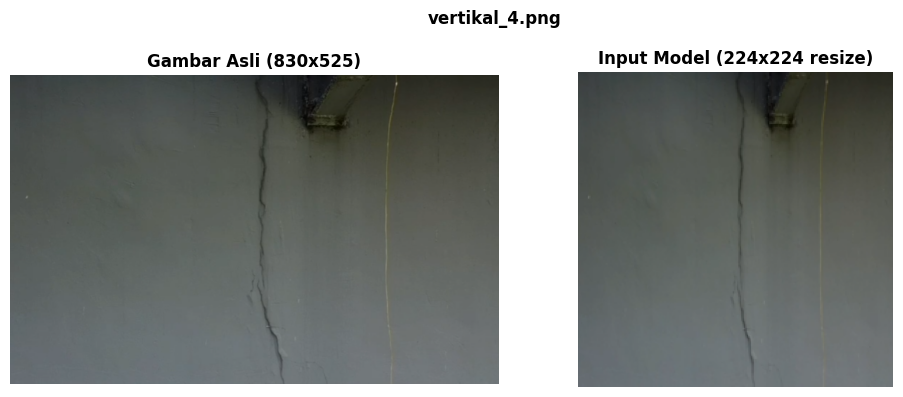

  Backend    : TFLite (cracksense_ResNet50.tflite)
  Metode     : TFLite + TTA (4 varian orientasi)
  Prediksi   : Vertikal
  Keyakinan  : 74.79%
    Diagonal    :   0.17% 
    Horizontal  :  25.04% ||||||||||
    Vertikal    :  74.79% |||||||||||||||||||||||||||||

=== Uji Gambar: ./dataset/test/vertikal_5.png ===


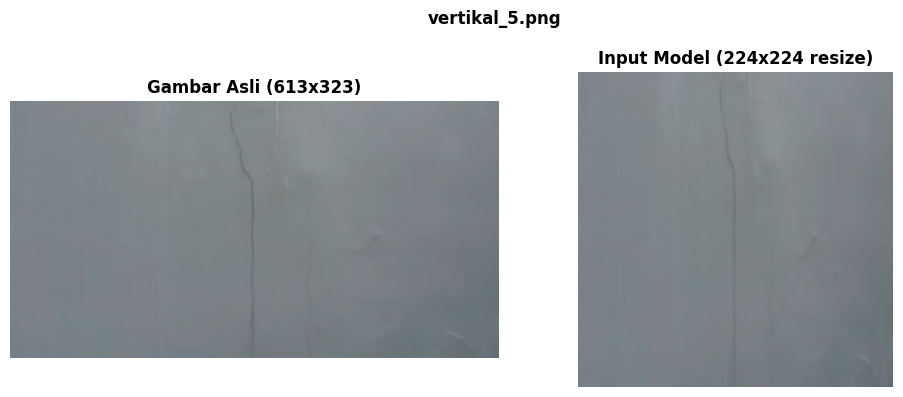

  Backend    : TFLite (cracksense_ResNet50.tflite)
  Metode     : TFLite + TTA (4 varian orientasi)
  Prediksi   : Vertikal
  Keyakinan  : 76.27%
    Diagonal    :   4.67% |
    Horizontal  :  19.05% |||||||
    Vertikal    :  76.27% ||||||||||||||||||||||||||||||

=== Uji Gambar: ./dataset/test/diagonal_1.png ===


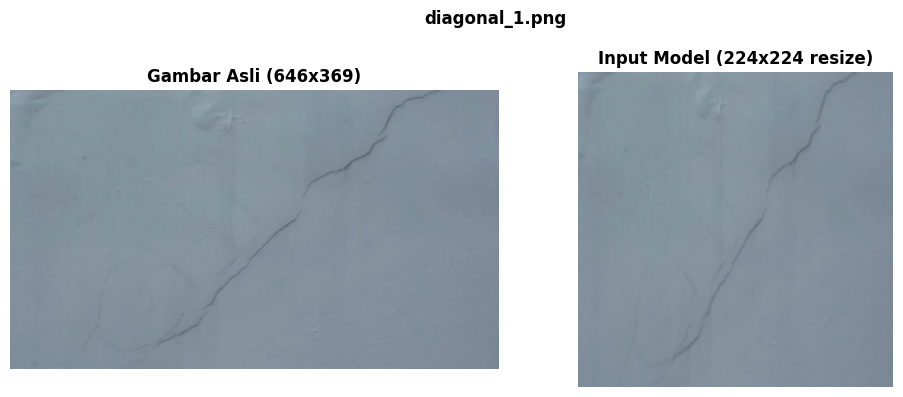

  Backend    : TFLite (cracksense_ResNet50.tflite)
  Metode     : TFLite + TTA (4 varian orientasi)
  Prediksi   : Diagonal
  Keyakinan  : 99.85%
    Diagonal    :  99.85% |||||||||||||||||||||||||||||||||||||||
    Horizontal  :   0.07% 
    Vertikal    :   0.07% 

=== Uji Gambar: ./dataset/test/diagonal_2.png ===


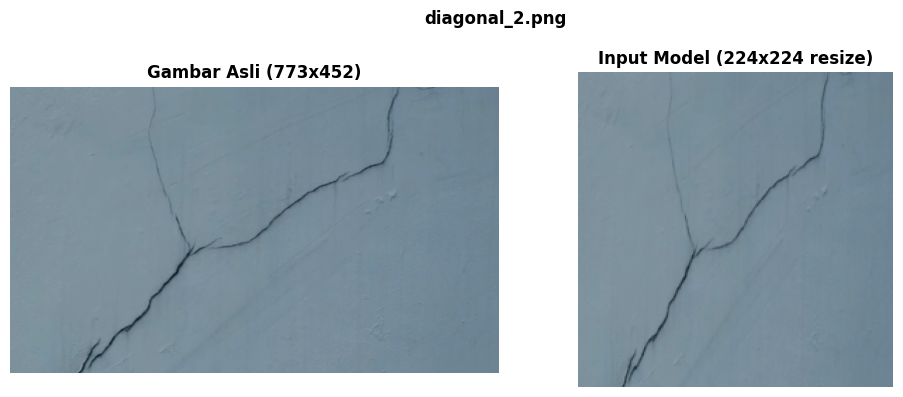

  Backend    : TFLite (cracksense_ResNet50.tflite)
  Metode     : TFLite + TTA (4 varian orientasi)
  Prediksi   : Diagonal
  Keyakinan  : 98.95%
    Diagonal    :  98.95% |||||||||||||||||||||||||||||||||||||||
    Horizontal  :   1.04% 
    Vertikal    :   0.00% 

=== Uji Gambar: ./dataset/test/diagonal_3.png ===


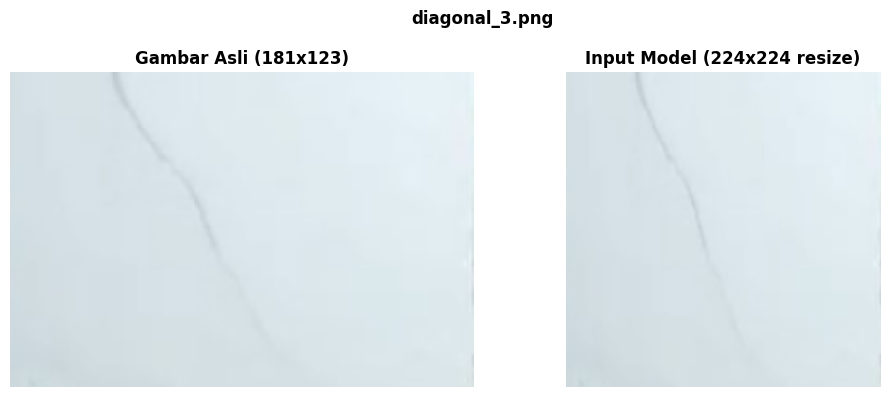

  Backend    : TFLite (cracksense_ResNet50.tflite)
  Metode     : TFLite + TTA (4 varian orientasi)
  Prediksi   : Diagonal
  Keyakinan  : 74.69%
    Diagonal    :  74.69% |||||||||||||||||||||||||||||
    Horizontal  :  16.21% ||||||
    Vertikal    :   9.10% |||

=== Uji Gambar: ./dataset/test/diagonal_4.png ===


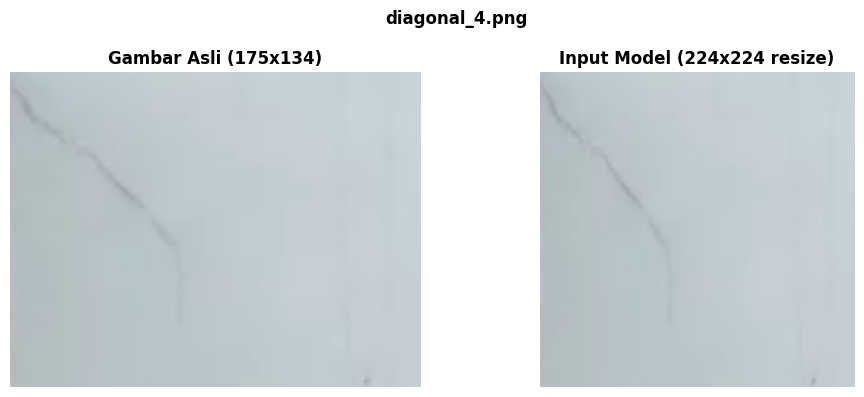

  Backend    : TFLite (cracksense_ResNet50.tflite)
  Metode     : TFLite + TTA (4 varian orientasi)
  Prediksi   : Diagonal
  Keyakinan  : 99.32%
    Diagonal    :  99.32% |||||||||||||||||||||||||||||||||||||||
    Horizontal  :   0.07% 
    Vertikal    :   0.61% 

=== Uji Gambar: ./dataset/test/diagonal_5.png ===


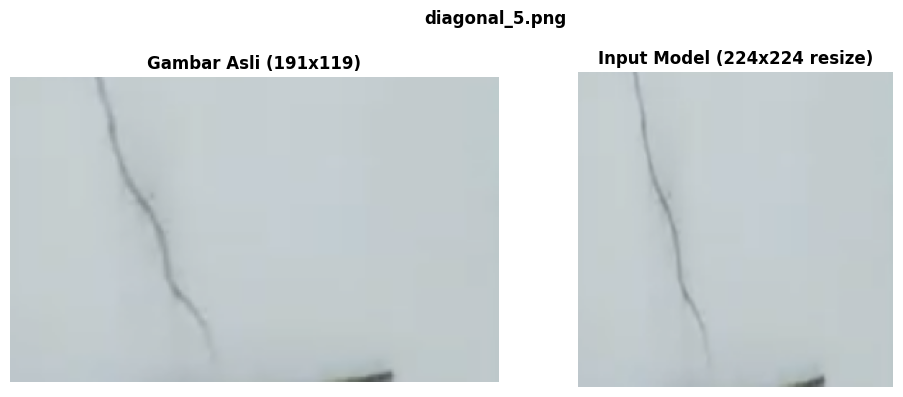

  Backend    : TFLite (cracksense_ResNet50.tflite)
  Metode     : TFLite + TTA (4 varian orientasi)
  Prediksi   : Vertikal
  Keyakinan  : 54.98%
    Diagonal    :  30.42% ||||||||||||
    Horizontal  :  14.60% |||||
    Vertikal    :  54.98% |||||||||||||||||||||

RINGKASAN HASIL PREDIKSI
  horizontal_1.png               -> Horizontal   (74.7%)
  horizontal_2.png               -> Horizontal   (73.6%)
  horizontal_3.png               -> Horizontal   (75.0%)
  horizontal_4.png               -> Horizontal   (69.3%)
  horizontal_5.png               -> Horizontal   (75.0%)
  vertikal_1.png                 -> Vertikal     (74.9%)
  vertikal_2.png                 -> Vertikal     (75.2%)
  vertikal_3.png                 -> Vertikal     (75.0%)
  vertikal_4.png                 -> Vertikal     (74.8%)
  vertikal_5.png                 -> Vertikal     (76.3%)
  diagonal_1.png                 -> Diagonal     (99.9%)
  diagonal_2.png                 -> Diagonal     (99.0%)
  diagonal_3.png         

In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image

TFLITE_PATH  = 'cracksense_ResNet50.tflite'
IMG_SIZE     = (224, 224)
CLASS_NAMES  = ['Diagonal', 'Horizontal', 'Vertikal']

TEST_IMAGE_PATHS = [
    './dataset/test/horizontal_1.png',
    './dataset/test/horizontal_2.png',
    './dataset/test/horizontal_3.png',
    './dataset/test/horizontal_4.png',
    './dataset/test/horizontal_5.png',

    './dataset/test/vertikal_1.png',
    './dataset/test/vertikal_2.png',
    './dataset/test/vertikal_3.png',
    './dataset/test/vertikal_4.png',
    './dataset/test/vertikal_5.png',

    './dataset/test/diagonal_1.png',
    './dataset/test/diagonal_2.png',
    './dataset/test/diagonal_3.png',
    './dataset/test/diagonal_4.png',
    './dataset/test/diagonal_5.png',   
]


print(f'Loading TFLite model: {TFLITE_PATH}')
interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(f'  Input  : shape={input_details[0]["shape"]}, dtype={input_details[0]["dtype"]}')
print(f'  Output : shape={output_details[0]["shape"]}, dtype={output_details[0]["dtype"]}')
print()


# ----------------------------------------------------------
# Fungsi preprocessing: simple resize ke 224x224
# PENTING: jangan pakai center_crop! (penyebab bug Vertikal semua)
# ----------------------------------------------------------
def preprocess_image_tflite(img_path):
    """
    Load & preprocess gambar untuk TFLite inference.
    
    Gunakan simple resize ke (224,224) + ResNet preprocessing.
    JANGAN pakai preserve_aspect + center_crop (bug: semua jadi Vertikal).
    """
    img_raw = tf.io.read_file(img_path)
    img = tf.image.decode_image(img_raw, channels=3, expand_animations=False)
    img = tf.cast(img, tf.float32)
    # Simple resize langsung ke 224x224
    img = tf.image.resize(img, IMG_SIZE)
    # ResNet50 preprocessing (mean subtraction BGR)
    img = tf.keras.applications.resnet.preprocess_input(img)
    # Tambah batch dimension & pastikan float32
    img = tf.expand_dims(img, axis=0)
    return img.numpy().astype(np.float32)


# ----------------------------------------------------------
# Fungsi prediksi TFLite (dengan TTA opsional)
# ----------------------------------------------------------
def tflite_predict_single(img_np):
    """Jalankan satu prediksi TFLite pada input numpy array."""
    interpreter.set_tensor(input_details[0]['index'], img_np)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    return output[0]   # shape: (3,)


def tflite_predict_with_tta(img_path):
    """
    Prediksi TFLite dengan Test-Time Augmentation (TTA).
    Rata-ratakan prediksi dari 4 orientasi gambar.
    """
    img_raw = tf.io.read_file(img_path)
    img = tf.image.decode_image(img_raw, channels=3, expand_animations=False)
    img = tf.cast(img, tf.float32)
    img_resized = tf.image.resize(img, IMG_SIZE)

    variants = [
        img_resized,
        tf.image.flip_left_right(img_resized),   # flip horizontal
        tf.image.flip_up_down(img_resized),       # flip vertikal
        tf.image.rot90(img_resized, k=1),         # rotasi 90
    ]

    preds_all = []
    for v in variants:
        v_norm = tf.keras.applications.resnet.preprocess_input(v)
        v_np   = tf.expand_dims(v_norm, 0).numpy().astype(np.float32)
        p = tflite_predict_single(v_np)
        preds_all.append(p)

    return np.mean(preds_all, axis=0)


# ----------------------------------------------------------
# Fungsi utama: prediksi gambar custom
# ----------------------------------------------------------
def predict_custom_images_tflite(image_paths, use_tta=True):
    results = []

    for test_image_path in image_paths:
        print(f'\n=== Uji Gambar: {test_image_path} ===')

        if not os.path.exists(test_image_path):
            print(f'  [!] File tidak ditemukan!')
            results.append({'path': test_image_path, 'prediction': None,
                            'confidence': None, 'probabilities': None})
            continue

        # Load gambar asli untuk tampilan
        pil_img = Image.open(test_image_path).convert('RGB')
        img_w, img_h = pil_img.size

        # Buat tampilan apa yang model terima (simple resize)
        img_display = np.array(pil_img.resize(IMG_SIZE[::-1]))

        # Tampilkan gambar asli vs input model
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        axes[0].imshow(pil_img)
        axes[0].set_title(f'Gambar Asli ({img_w}x{img_h})', fontweight='bold')
        axes[0].axis('off')
        axes[1].imshow(img_display)
        axes[1].set_title(f'Input Model (224x224 resize)', fontweight='bold')
        axes[1].axis('off')
        plt.suptitle(os.path.basename(test_image_path), fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

        # Prediksi
        if use_tta:
            preds  = tflite_predict_with_tta(test_image_path)
            metode = 'TFLite + TTA (4 varian orientasi)'
        else:
            img_np = preprocess_image_tflite(test_image_path)
            preds  = tflite_predict_single(img_np)
            metode = 'TFLite single inference'

        pred_idx   = int(np.argmax(preds))
        confidence = float(preds[pred_idx] * 100)
        pred_class = CLASS_NAMES[pred_idx]

        print(f'  Backend    : TFLite ({TFLITE_PATH})')
        print(f'  Metode     : {metode}')
        print(f'  Prediksi   : {pred_class}')
        print(f'  Keyakinan  : {confidence:.2f}%')
        for i, cls in enumerate(CLASS_NAMES):
            bar = '|' * int(preds[i] * 40)
            print(f'    {cls:12s}: {preds[i]*100:6.2f}% {bar}')

        results.append({
            'path':          test_image_path,
            'prediction':    pred_class,
            'confidence':    confidence,
            'probabilities': {cls: float(preds[i]*100) for i, cls in enumerate(CLASS_NAMES)}
        })

    return results


# ----------------------------------------------------------
# Jalankan prediksi
# ----------------------------------------------------------
print('=' * 60)
print('INFERENSI TFLITE - GAMBAR CUSTOM')
print('=' * 60)
print(f'Model : {TFLITE_PATH}')
print(f'Kelas : {CLASS_NAMES}')
print()

custom_results = predict_custom_images_tflite(TEST_IMAGE_PATHS, use_tta=True)

# Ringkasan
print()
print('=' * 60)
print('RINGKASAN HASIL PREDIKSI')
print('=' * 60)
for r in custom_results:
    if r['prediction'] is not None:
        fname = os.path.basename(r['path'])
        print(f'  {fname:30s} -> {r["prediction"]:12s} ({r["confidence"]:.1f}%)')


## Simpan Model & Konversi ke TFLite

In [10]:
model.save(f'cracksense_{MODEL_NAME}.keras')
print(f'Model disimpan: cracksense_{MODEL_NAME}.keras')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_filename = f'cracksense_{MODEL_NAME}.tflite'
with open(tflite_filename, 'wb') as f:
    f.write(tflite_model)

size_mb = os.path.getsize(tflite_filename) / (1024*1024)
print(f'TFLite disimpan: {tflite_filename} ({size_mb:.2f} MB)')

NameError: name 'model' is not defined